# Business Understanding

## Problem Statement
The goal of this project is to develop a machine learning model capable of identifying the smallest set of features that can reliably predict whether an early-stage startup will succeed or fail. Additionally, the project will explore how combinations of factors influence the startup's growth and long-term performance.

## Business Objectives

### Background
Few startups rapidly scale into successful businesses, while many others fail due to factors like poor market fit, insufficient funding, lack of product traction, etc. Investors, founders, and analysts often rely on typical benchmarks, historical records of success, and experience to evaluate a startup's potential. However, these methods may overlook some complex relationships hidden within the data.

This project will explore whether machine learning can be used to identify the most common and key patterns associated with startup success or failure.

The dataset contains startup-related information such as funding rounds, team size, market potential, revenue, investory type, and more.

### Objectives
The primary business objective is to use the above factors in building predictive models that estimate the likelihood of success.

Secondary objectives include:
* Identifying which startup features have the strongest influence on success
* Understand how feature combinations influce startup outcomes
* Provide investors and analysts with a more data-driven approach to evaluating the potential of a startup



## Business Success Criteria

The project will be considered successful if the final machine learning model successfully predicts outcomes with reasonable reliability.

Additional success criteria include:
* The development of multiple models to compare and determine which approach performs best
* Producing interpretable results identifying which features contributed most to the prediction
* Demonstrating that machine learning can evaluate startups and support decision-making processes for investors, founders, and analysts

## Situational & Data Assessment

### Resources
The following resources will be used in this project:
* Business and financial information from startups
* Python programming language
* Jupyter Notebook dev environment
* Data science libraries including pandas, NumPy, matplotlib, seaborn, and scikit-learn
* ML algorithms and models such as Logistic Regression, Regularization, and Decision Trees

### Assumptions & Constraints
#### Assumptions:
1. The dataset accurately represents real startup business data
2. The labeled outcomes correctly identify success or failure
3. The dataset contains enough information to support early-stage startup predictions

#### Constraints
1. The project is currently limited to the data provided in the dataset. Additional sourced data is out of scope.
2. Computational limitations may reduce the ability to test highly complex models
3. There may be a large number of missing or unusable values in the dataset

### Risks and Contingencies
1. The dataset may contain a large number of missing, incomplete, or unusable values
2. Success or failure may actually be influenced by factors not included in the dataset


# Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [3]:
# Load the dataset
data = pd.read_csv('data/startup_success_dataset.csv')

In [4]:
# Display the first few rows of the dataset to understand its structure
data.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [5]:
# Display the shape of the dataset to better understand the number of samples and features
shape = data.shape
print(f"Rows:{shape[0]} \nColumns: {shape[1]}")

Rows:100000 
Columns: 11


In [6]:
# Display a summary of the dataset to understand its data types and identify any missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


In [7]:
# Display basic statistical details to understand numerical distributions.
data.describe()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06


In [8]:
# Display basic statistical details to understand categorical distributions.
data.describe(include = 'object')

,investor_type,sector,founder_background,outcome
count,100000,100000,100000,100000
unique,4,7,4,3
top,tier2_vc,Crypto,first_time,Failure
freq,35327,14456,39980,55610


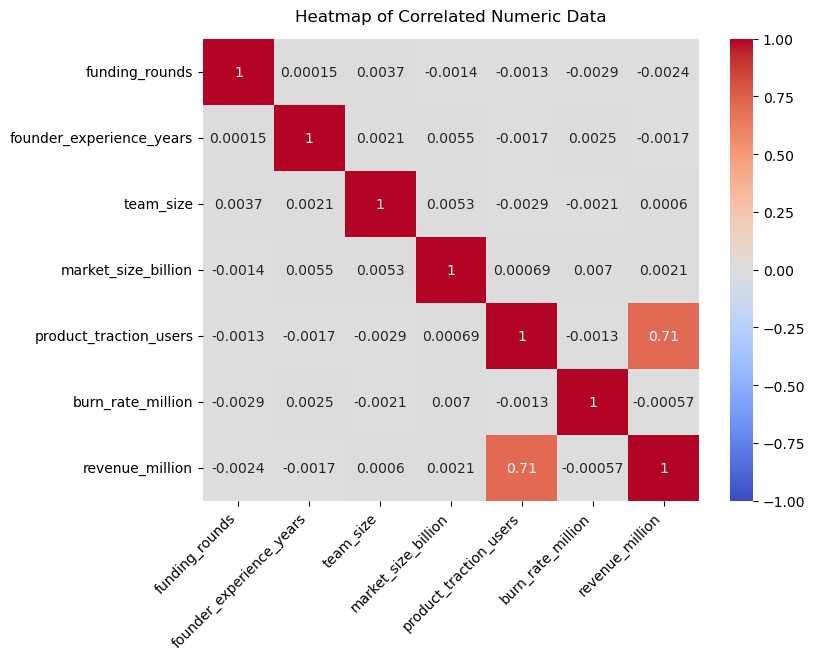

In [9]:
# Display a heatmap of all data with numeric values to visualize their correlations before the data is cleaned.

# Store the numeric data in a variable
data_numeric = data.select_dtypes(include = ['int64', 'float64'])

# Set the plot size, settings, and title.
plt.figure(figsize = (8, 6))
sns.heatmap(data_numeric.corr(), annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.xticks(rotation=45, ha='right')
plt.title('Heatmap of Correlated Numeric Data', y = 1.02)
plt.show()

The heatmap reveals that product_traction_users and revenue_million are highly correlated. This appears to be the strongest numeric correlation in the raw dataset.
However, all other numeric correlations appear near 0. This could mean highly synthetic data, or the relationships are nonlinear.

Based on this data, it may be beneficial to utilize _revenue_million_ and _product_traction_users_ in the initial model.
Additionally, a Decision Tree may find strong nonlinear patterns where the numeric correlation heatmap did not.

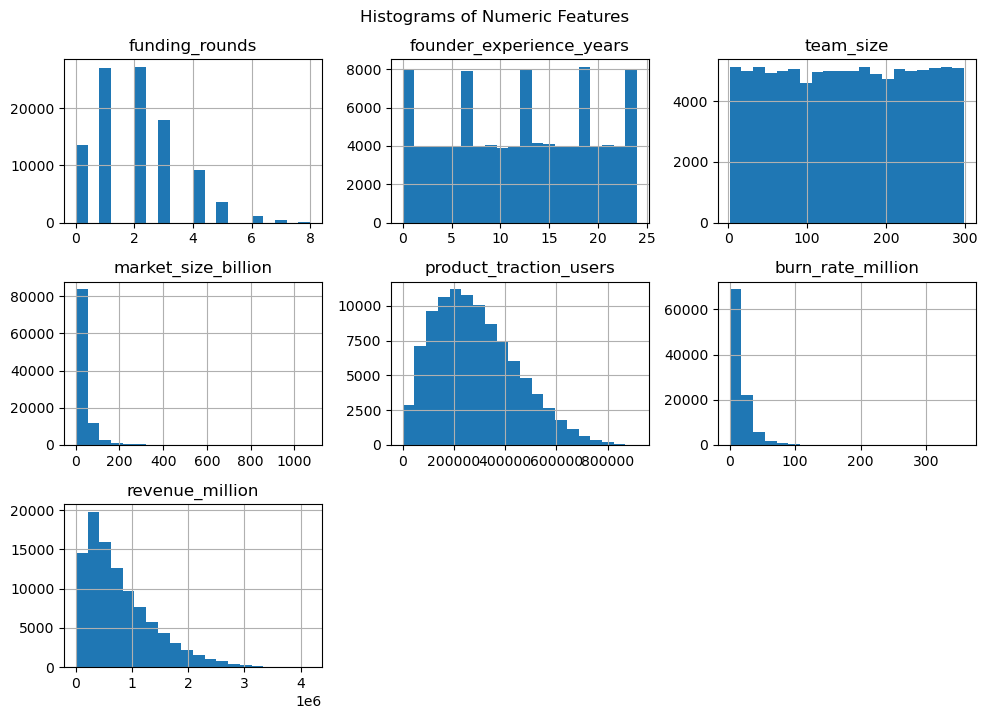

In [10]:
# Display a histogram matrix to quickly identify outliers and skewed data
data_numeric.hist(figsize = (10, 7), bins = 20)
plt.tight_layout()
plt.suptitle('Histograms of Numeric Features', y = 1.02)
plt.show()

Several feeatures exhibit a right-skewed histogram. This likely indicates that scaling and log transformations will be necessary later.

Additionally, features like _founder_experience_years_ and _team_size_ display unusually consistnt spikes and uniformity. This potentially means synthetic data.

_market_size_billion_ has a high quantitative value of startups operating in unusually large markets. This potentially indicates outliers.

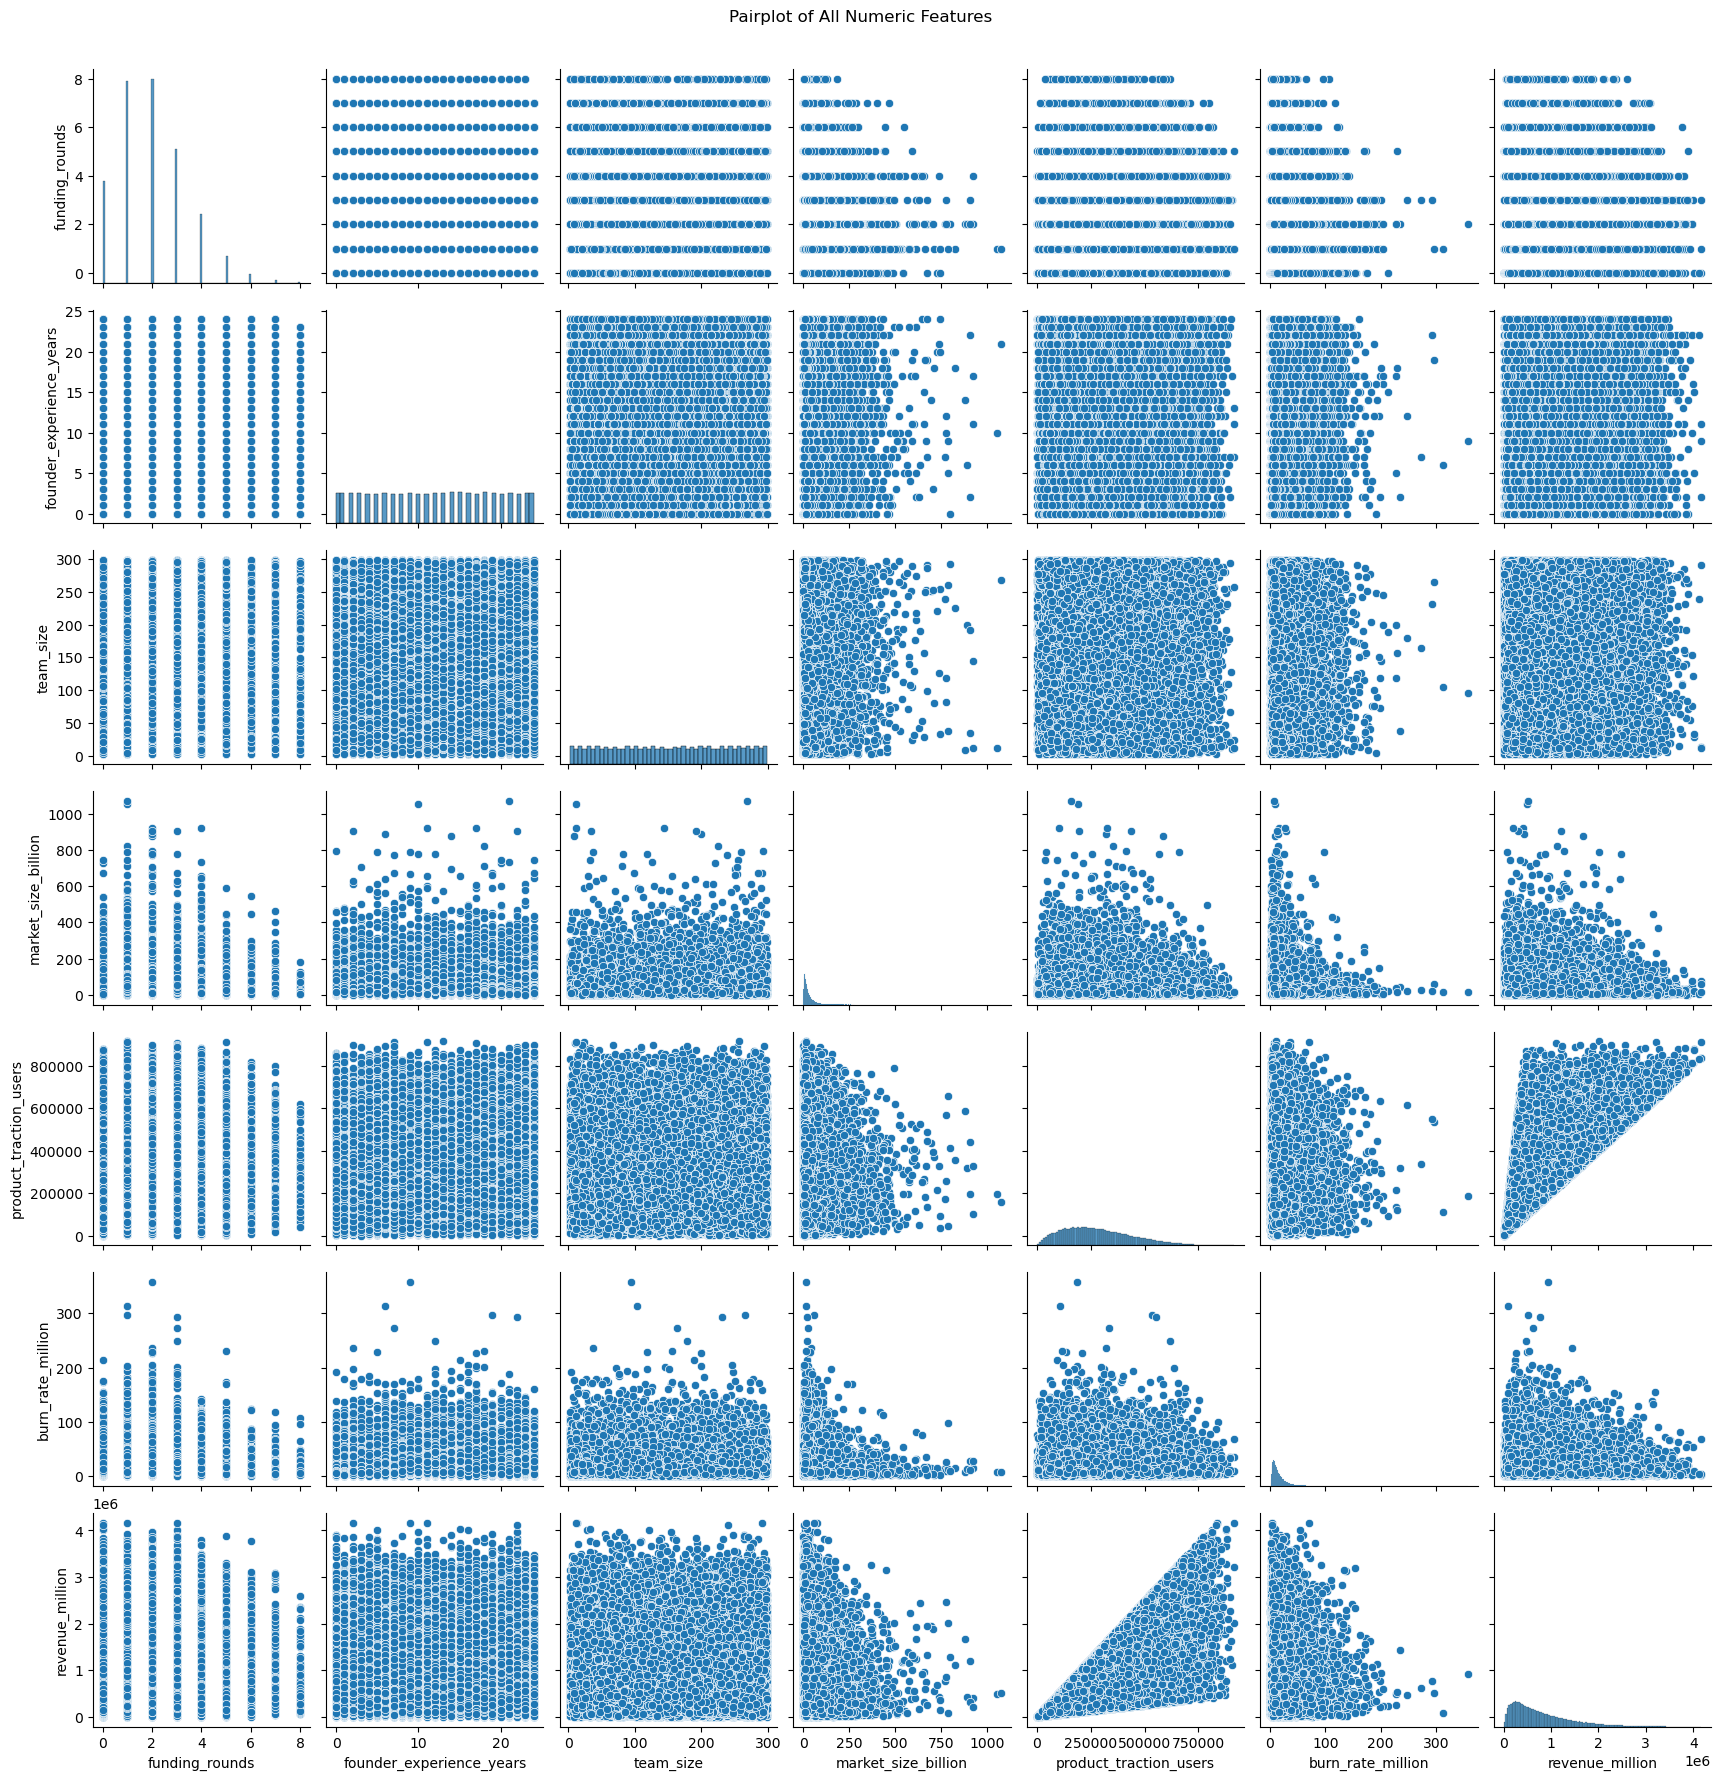

In [11]:
# Pair plot of all numeric features, visualizing their relationships and distributions.
sns.pairplot(data)
plt.suptitle('Pairplot of All Numeric Features', y = 1.02)
plt.show()

Based on the pairplot above, four features appear to have an identifiable correlation with the revenue factor, which was previously identified as a potential strong influence in startup outcome. These features include _funding_rounds_, _market_size_billion_, _product_traction_users_, and _burn_rate_million_.

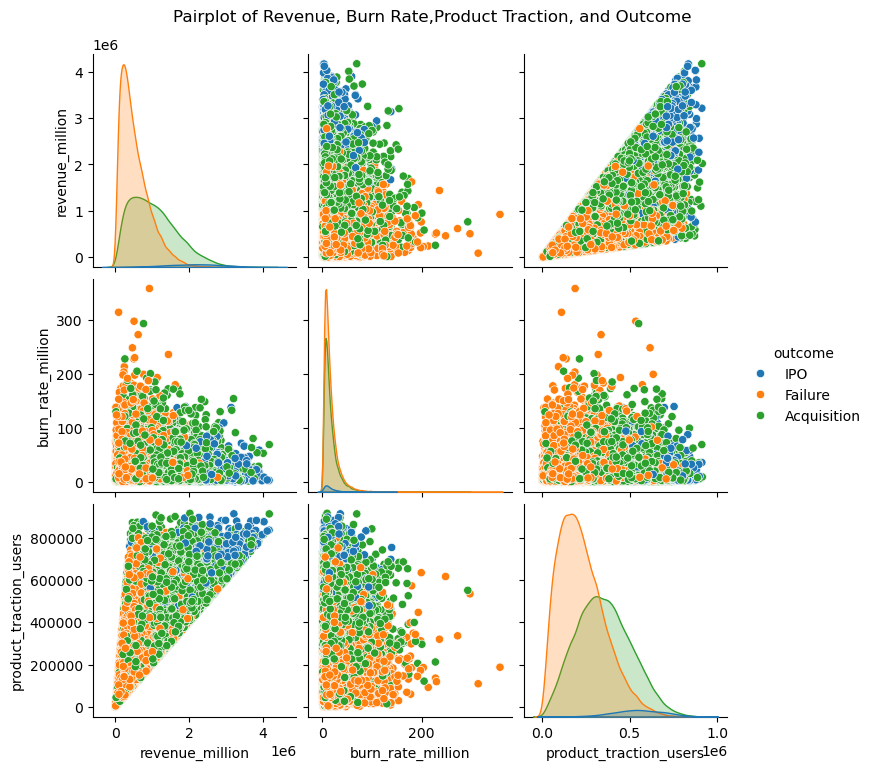

In [12]:

#Pair plot of the selected features
sns.pairplot(data[['revenue_million', 'burn_rate_million', 'product_traction_users', 'outcome']], hue = 'outcome')
plt.suptitle('Pairplot of Revenue, Burn Rate,Product Traction, and Outcome', y = 1.02)
plt.show()

Pair plots revealed a strong relationship between product traction and revenue across startup outcomes. Additionally, companies that reached IPO status generally exhibited the highest user traction and highest revenues. Contrary, failed startups typically had the lowest revenue and user count.

Furthermore, burn rate revealed a strong relationship with revenue and product traction. The data suggests that startups with higher burn rates had lower overall revenue and product traction.

Since revenue also demonstrates a strong relationship with startup outcomes, these features may indirectly contribute to predicting outcome classifications. Further analysis and modeling will help determine the strength and significance of these relationships.

Finally, the plot demonstrates possible outliers that may require cleaning before modeling.

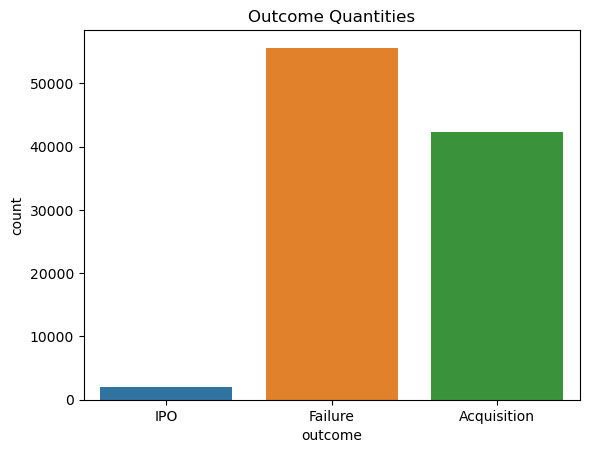

In [13]:
# Explore the target variable
data['outcome'].value_counts()

# Visualize outcome quantities
sns.countplot(data = data, x = 'outcome', hue = 'outcome')
plt.title('Outcome Quantities')
plt.show()

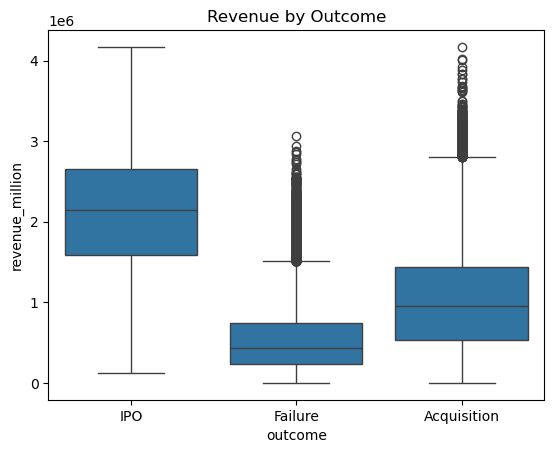

In [14]:
# Visualize an outcome boxplot
sns.boxplot(data, x = 'outcome', y = 'revenue_million')
plt.title('Revenue by Outcome')
plt.show()

This boxplots confirms earlier suspicions of revenue potentially being a strong driver of outcome.
* Startups that reached an IPO appeared to generate the highest revenues. The median appears around ~$2.1M, while most IPO companies fall between ~$1.5 and ~$2.6M
* Failed companies typically produced the lowest revenues with the median falling around ~$400k. However, most failed startups fall between ~$250k and ~$700k
* Aquisitions typically happen between ~$500k and ~$1.5M in revenue. 

In [15]:
# Explore the categorical values in the dataset
categorical_columns = data.select_dtypes(include = ['object']).columns
for column in categorical_columns:
    print(f"unique values in {column}: {data[column].unique()}")

unique values in investor_type: ['tier2_vc' 'none' 'angel' 'tier1_vc']
unique values in sector: ['Health' 'Fintech' 'SaaS' 'Ecommerce' 'Climate' 'Crypto' 'AI']
unique values in founder_background: ['academic' 'first_time' 'ex_bigtech' 'serial_founder']
unique values in outcome: ['IPO' 'Failure' 'Acquisition']


In [16]:
# Explore the investor_type feature where the value is 'none' to understand what the 'none' value represents in the context of the dataset.
data[data['investor_type'] == 'none'].head(10).reset_index(drop = True)

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
1,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
2,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition
3,2,24,238,44.136744,83347,20.866993,1.793094e+05,none,Crypto,first_time,Failure
4,2,23,173,13.238911,194574,36.568934,1.215045e+05,none,Climate,ex_bigtech,Acquisition
5,4,20,91,182.133589,386217,12.931544,1.585512e+06,none,Fintech,serial_founder,Acquisition
6,1,2,256,6.518649,210769,25.334794,8.110615e+05,none,Crypto,serial_founder,Failure
7,6,10,146,11.315106,92870,10.186482,2.685505e+05,none,Health,serial_founder,Acquisition
8,1,12,144,7.792863,287985,22.902180,5.619510e+05,none,Fintech,ex_bigtech,Failure
9,4,18,62,16.320939,339094,7.672094,9.782596e+05,none,Health,serial_founder,Acquisition


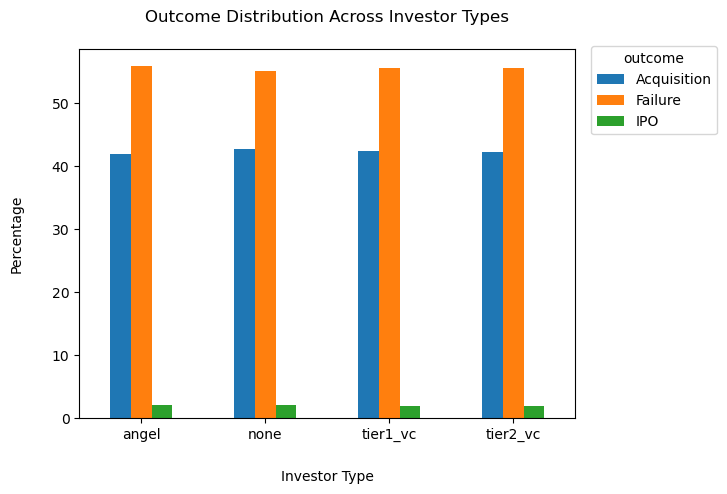

In [17]:
# Inspect the investor_type feature to understand the outcome distribution across investor types.
(pd.crosstab(data['investor_type'], data['outcome'], normalize = 'index') * 100).plot(kind = 'bar', stacked = False)
plt.title('Outcome Distribution Across Investor Types', y = 1.05)
plt.ylabel('Percentage', labelpad = 20)
plt.xlabel('Investor Type', labelpad = 20)
plt.legend(title = 'outcome', bbox_to_anchor = (1.30, 1.025), loc = 'upper right')
plt.xticks(rotation = 360)
plt.show()

The outcome distribution is consistent across investor types. This feature may not have a high standalone contribution to outcome predictions. However, it may contribute predictive value when combined with other variables.

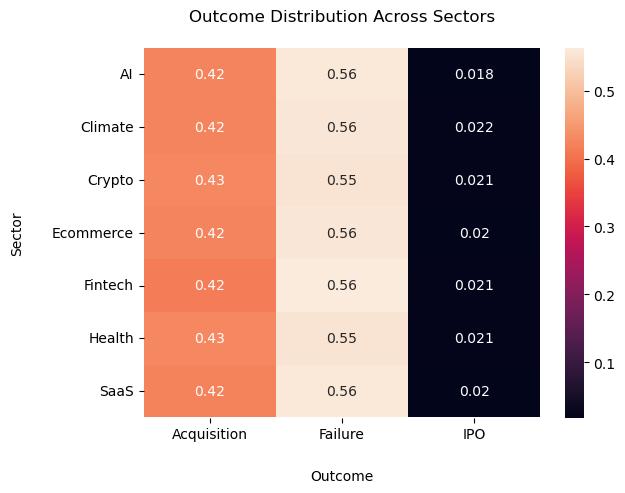

In [18]:
sector_table = pd.crosstab(
    data['sector'],
    data['outcome'],
    normalize='index'
)

sns.heatmap(sector_table, annot=True)
plt.title('Outcome Distribution Across Sectors', y = 1.05)
plt.ylabel('Sector', labelpad = 20)
plt.xlabel('Outcome', labelpad = 20)
plt.show()

This heatmap suggests that business sector has a relatively weak standalone relationship with the outcome of a startup. Outcome distributions remain highly consistent across all sectors, and failure represents the majority. IPOs are consistently rare. While business sector may not have a standalone significance in outcome predictions, it may contribute predictive value when combined with other variables.

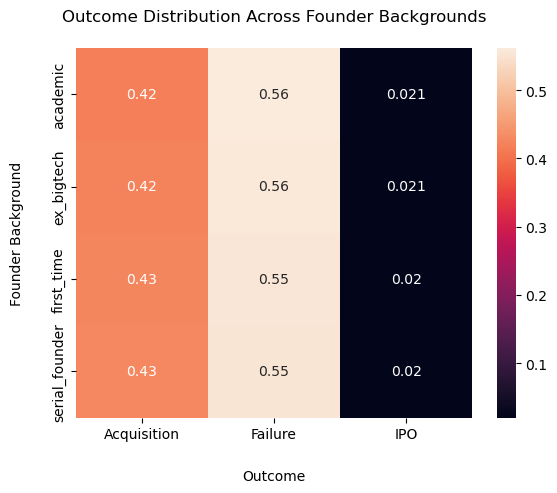

In [19]:
founder_background_outcome = pd.crosstab(
    data['founder_background'],
    data['outcome'],
    normalize = 'index'
)

sns.heatmap(founder_background_outcome, annot = True)
plt.title('Outcome Distribution Across Founder Backgrounds', y = 1.05)
plt.ylabel('Founder Background', labelpad = 20)
plt.xlabel('Outcome', labelpad = 20)
plt.show()

This heatmap suggests that founder background has a relatively weak standalone relationship with the outcome of a startup. Outcome distributions remain highly consistent across all background types, and failure represents the majority. IPOs are consistently rare. While founder background may not have a standalone significance in outcome predictions, it may contribute predictive value when combined with other variables.

# Data Cleaning

In [20]:
# Verify that all features have no missing values.
data.isnull().sum()

funding_rounds              0
founder_experience_years    0
team_size                   0
market_size_billion         0
product_traction_users      0
burn_rate_million           0
revenue_million             0
investor_type               0
sector                      0
founder_background          0
outcome                     0
dtype: int64

In [21]:
# verify that there are no duplicate rows.
print(f"Number of duplicate rows: {data.duplicated().sum()}")

Number of duplicate rows: 0


In [22]:
# Copy the original dataset to a new variable to clean and prepare it for modeling.
model_data = data.copy()

In [23]:
# Encode the target variable 'outcome' for modeling purposes.

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit the label_encoder to the 'outcome'
model_data['outcome'] = label_encoder.fit_transform(model_data['outcome'])

In [24]:
# Save the mapping of the original outcome labels to their encoded values for future reference.
label_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))
print(label_mapping)

{'Acquisition': np.int64(0), 'Failure': np.int64(1), 'IPO': np.int64(2)}


In [25]:
# One-hot encode the remaining categorical features.
model_data = pd.get_dummies(
    model_data,
    columns = ['investor_type', 'sector', 'founder_background'],
    drop_first = True
)

# Modeling

### Model 1
Baseline model on raw features + logistic regression

In [26]:
# Train a baseline logistic regression model to predict startup outcomes based on all features and lightly cleaned data.

# Separate the features (X) and the target variable (y | outcome).
X = model_data.drop('outcome', axis = 1)
y = model_data['outcome']

In [27]:
# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [28]:
# Train the logistic regression model
model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_

LogisticRegression(max_iter=1000, random_state=42)

In [29]:
# Make predictions on the test set
y_predictions = model.predict(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [30]:
# Evaluate the model's performance using accuracy_score
accuracy = accuracy_score(y_test, y_predictions)
print(f'Accuracy is: {accuracy: .2f}')

Accuracy is:  0.64


In [31]:
# Explore the classification report to better understand performance across precision, recall, and f1-score for each class.
print(classification_report(y_test, y_predictions))

              precision    recall  f1-score   support

           0       0.58      0.60      0.59      8467
           1       0.70      0.70      0.70     11122
           2       0.17      0.02      0.04       411

    accuracy                           0.64     20000
   macro avg       0.48      0.44      0.44     20000
weighted avg       0.63      0.64      0.64     20000



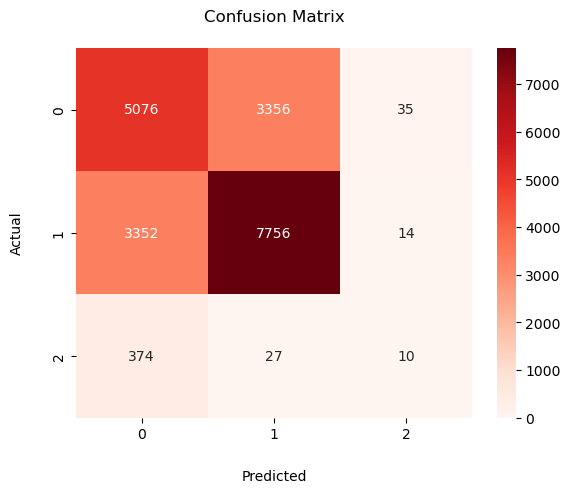

In [32]:
# Visualize the results using a confusion matrix to better understand the quantitative performance across true positives/negatives, and false positives/negatives.
cmatrix = confusion_matrix(y_test, y_predictions)

sns.heatmap(cmatrix, annot=True, fmt = 'd', vmin = 0, cmap = 'Reds')

plt.title('Confusion Matrix', y = 1.05)
plt.xlabel('Predicted', labelpad = 20)
plt.ylabel('Actual', labelpad = 20)

plt.show()

### Model 2
Scaled features + logistic regression

In [33]:
# Scale the data using StandardScaler() in hopes of improving the model performance. 
scaler = StandardScaler()

# scale the X datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
# Train a new logistic regression model using the scaled data to explore whether the accuracy improves.
model2 = LogisticRegression(random_state = 42, max_iter = 1000)
model2.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
# Make new predictions using the scaled data
y_prediction_model2= model2.predict(X_test_scaled)

# Evaluate the model's performance using accuracy_score
accuracy_scaled_data = accuracy_score(y_test, y_prediction_model2)
print(f'Accuracy is: {accuracy_scaled_data: .2f}')

Accuracy is:  0.74


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [36]:
# Explore the classification report related to the scaled data.
print(classification_report(y_test, y_prediction_model2))

              precision    recall  f1-score   support

           0       0.72      0.66      0.69      8467
           1       0.76      0.83      0.80     11122
           2       0.65      0.27      0.38       411

    accuracy                           0.74     20000
   macro avg       0.71      0.58      0.62     20000
weighted avg       0.74      0.74      0.74     20000



Scaling the data did improve the model by 15.625%.
Next, I'll explore whether log transformations on the heavily right-skewed data discovered in early EDA further improves the model. These include burn_rate_million, revenue_million, and market_size_billion.

### Model 3
Log transformation of right-skewed features + scaled data + logistic regression

In [37]:
# Explore the data statistics of the right-skewed features to better understand outliers before applying a log transformation.
data_numeric[['market_size_billion',
              'revenue_million',
              'burn_rate_million',
              'product_traction_users']].describe(
                  percentiles=[0.95, 0.99, 0.999]
              ).T

,count,mean,std,min,50%,95%,99%,99.9%,max
market_size_billion,100000.0,33.203875,43.034753,0.288738,20.158063,1.047059e+02,2.073400e+02,4.464779e+02,1.072434e+03
revenue_million,100000.0,782819.143683,608506.910922,1344.810178,621362.389435,2.005913e+06,2.700754e+06,3.396290e+06,4.168443e+06
burn_rate_million,100000.0,16.776213,15.711368,0.279763,12.169059,4.558278e+01,7.817620e+01,1.371230e+02,3.574915e+02
product_traction_users,100000.0,285422.832730,159323.885405,668.000000,264989.500000,5.799981e+05,7.030607e+05,8.178028e+05,9.152030e+05


In [38]:
# Create a new set of log transformed features
model_data['log_market_size'] = np.log1p(model_data['market_size_billion'])
model_data['log_revenue'] = np.log1p(model_data['revenue_million'])
model_data['log_burn_rate'] = np.log1p(model_data['burn_rate_million'])
model_data['log_product_traction'] = np.log1p(model_data['product_traction_users'])

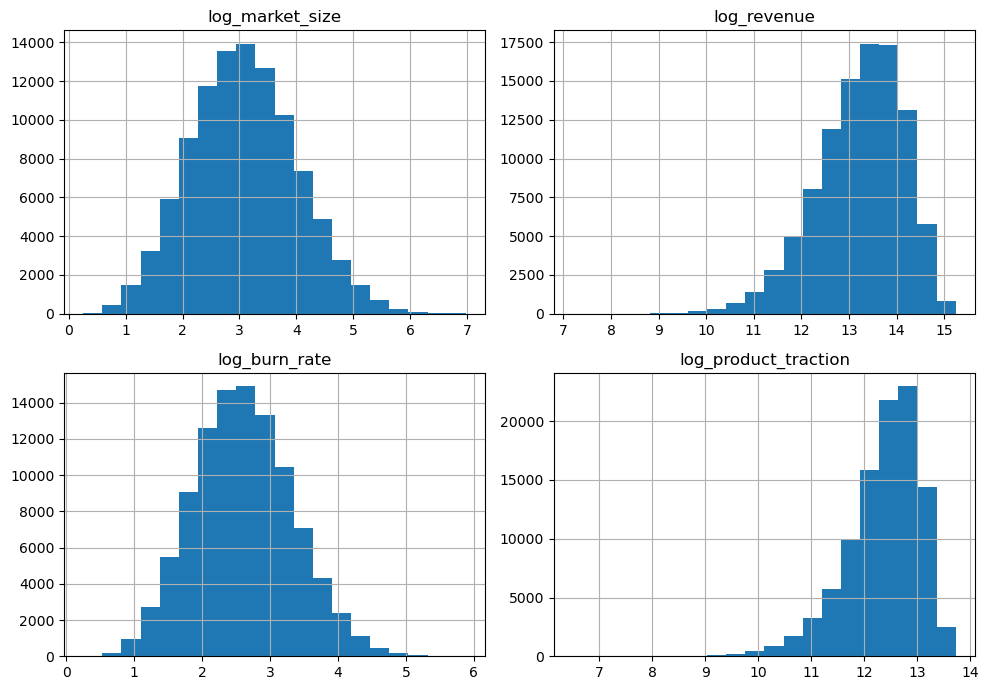

In [39]:
# Place the new log feeatures in a variable.
log_features = model_data[
    ['log_market_size',
    'log_revenue',
    'log_burn_rate',
    'log_product_traction']
]

log_features.hist(figsize = (10, 7), bins = 20)
plt.tight_layout()
plt.show()

Logarithmic transformations successfully reduced the strong right skew observations, but mildly left skewed revenue and burn rate.
However, this is not considered problematic as the goal was simply to reduce extreme skewness that could negatively impact the model. That was accomplished.

In [40]:
# Build a new dataset with the log transformed features and target variable
X = model_data.drop(columns = [
    'outcome',
    'market_size_billion',
    'revenue_million',
    'burn_rate_million',
    'product_traction_users'
])

y = model_data['outcome']

In [41]:
# Split the log transformed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [42]:
# Scale the log transformed data using StandardScaler()
scaler_model3 = StandardScaler()

# Scale the training and testing data
X_train_scaled_model3 = scaler_model3.fit_transform(X_train)
X_test_scaled_model3 = scaler_model3.transform(X_test)

In [43]:
# Train a new logistic regression model (Model 3) using the log transformed and scaled data to explore whether the accuracy improves.
model3 = LogisticRegression(random_state = 42, max_iter = 1000)
model3.fit(X_train_scaled_model3, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_

LogisticRegression(max_iter=1000, random_state=42)

In [44]:
# Make new predictions using the scaled data
y_prediction_model3 = model3.predict(X_test_scaled_model3)

# Evaluate the model's performance using accuracy_score
accuracy_model3 = accuracy_score(y_test, y_prediction_model3)
print(f'Accuracy is: {accuracy_model3: .2f}')

Accuracy is:  0.74


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [45]:
# Explore the classification report related to log transformed and scaled data.
print(classification_report(y_test, y_prediction_model3))

              precision    recall  f1-score   support

           0       0.70      0.69      0.69      8467
           1       0.77      0.80      0.79     11122
           2       0.64      0.22      0.32       411

    accuracy                           0.74     20000
   macro avg       0.70      0.57      0.60     20000
weighted avg       0.74      0.74      0.74     20000



Overall, the accuracy performance of Model 3 was unchanged when compared to the results of Model 2.
The transformed features provided no additional predictive value for the logistic regression model.
The biggest weeakness across all 3 models is the low recall of the class 2 (IPO) outcome. It is likely due to an imbalance of classifications where class 2 makes up nearly 2% of the overall data. There may not be enough training data for this classification.

Therefore, a decision tree model may better understand the relationships between features.

### Model 4
Decision Tree baseline model

In [46]:
# Build a basic decision tree model to explore its performance capabilities in comparison to logistic regression.

# Split the features from the target variable.
X = model_data.drop(columns = [
    'outcome',
    'market_size_billion',
    'revenue_million',
    'burn_rate_million',
    'product_traction_users'
])

y = model_data['outcome']

In [47]:
# SPlit the training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [48]:
# Train the baseline decision tree model
tree_model4 = DecisionTreeClassifier(random_state = 42)
tree_model4.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [49]:
# Generate predictions on the test set
y_predictions_tree4 = tree_model4.predict(X_test)


In [50]:
# Evaluate the performance using accuracy_score
accuracy_tree4 = accuracy_score(y_test, y_predictions_tree4)
print(f"Accuracy is: {accuracy_tree4: .2f}")

Accuracy is:  0.64


In [51]:
# Explore the classification report related to the decision tree model.
print(classification_report(y_test, y_predictions_tree4))

              precision    recall  f1-score   support

           0       0.58      0.58      0.58      8467
           1       0.70      0.70      0.70     11122
           2       0.30      0.32      0.31       411

    accuracy                           0.64     20000
   macro avg       0.53      0.53      0.53     20000
weighted avg       0.64      0.64      0.64     20000



Baseline Decision Tree model did not perform better than the logistic regression Model 2 or Model 3. However, the class 2 (IPO) outcome had a recognizable increase in Recall. In fact, it is the highest class 2 recall of all four models built thus far. The recall recorded from the Decision Tree presented 45% improvement from Model 3.

Nonetheless, the overall accuracy score (64%) was a recognizable decrease from the highest accuracy score of 74% produced from previous models.

Next, Model 5 will include a grid search function to identify the best parameters for the Decision Tree model. Additionally, the model will be focus on optimizing for the F1 scoring model. By optimizing for F1, the Decision Tree model will treat class 2 (IPO) with the same weight of importance as classes 0 and 1 during training. Ideally, this should improve the F1 score, hopefully increasing our highest acheived accuracy score.

### Model 5
Decision Tree + GridSearchCV + F1 scoring model

In [52]:
# Create a parameter grid for tuning the decision tree model in hopes of improving performance.
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'class_weight': [None, 'balanced']
}

In [53]:
# Create the grid search object. This will use the parameter grid and the f1_macro scoring metric.
grid_model5 = GridSearchCV(
    DecisionTreeClassifier(random_state = 42),
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1_macro',
    n_jobs = -1
)

# Fit the grid search model to the training data.
grid_model5.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [3, 5, 7, 10, 15],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1_macro')

In [54]:
# Display the best parameter settings found by the grid search model.
grid_model5.best_params_

{'class_weight': None,
 'max_depth': 10,
 'min_samples_leaf': 10,
 'min_samples_split': 2}

In [55]:
# Display the best f1 score achieved by the grid search model.
print(f"F1 Score: {grid_model5.best_score_: .2f}")

F1 Score:  0.58


In [56]:
# Use the best estimator from the grid search to make predictions on the test set and evaluate its performance.
tree_model5 = grid_model5.best_estimator_

y_prediction_model5 = tree_model5.predict(X_test)

In [57]:
# Evaluate the model's performance using classification report and accuracy score.
print(classification_report(y_test, y_prediction_model5))
print(f'Accuracy: {accuracy_score(y_test, y_prediction_model5):.2f}')

              precision    recall  f1-score   support

           0       0.68      0.64      0.66      8467
           1       0.75      0.80      0.77     11122
           2       0.52      0.22      0.31       411

    accuracy                           0.72     20000
   macro avg       0.65      0.55      0.58     20000
weighted avg       0.71      0.72      0.72     20000

Accuracy: 0.72


Background dataset has 80000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=80000 when initializing the masker.


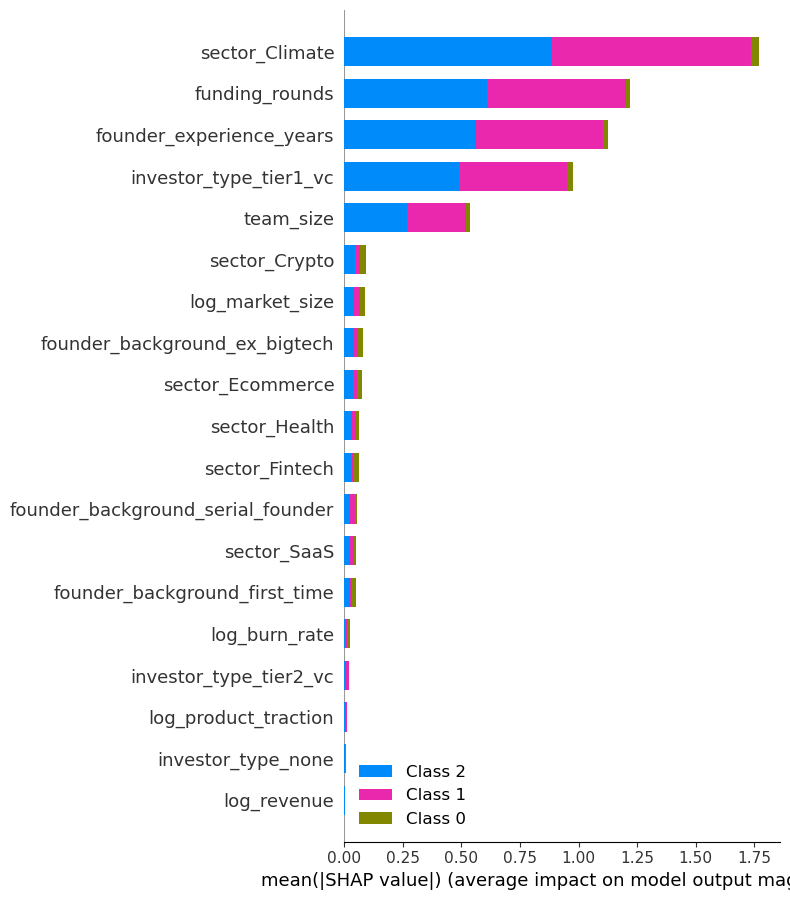

In [58]:
import shap

# Use a sample so SHAP runs faster
X_sample = X_test_scaled[:1000]

# Create SHAP explainer for logistic regression model
explainer = shap.Explainer(
    model2,
    X_train_scaled,
    max_samples = int(len(X_train_scaled) * 0.5)
)

# Calculate SHAP values
shap_values = explainer(X_sample)

# Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)

# Findings

I started this project with one main question: can early-stage startup factors help predict whether a startup will succeed or fail? The results suggest that they can, but with some important limitations.

First, I explored the data and found that several features which include market size, revenue, burn rate, and product traction, were heavily skewed. Initially, these distributions were assummed to be errors in the data. However, after performing logarithmic transformations and evaluating the variables through Model 3, I found evidence of the contrary.

Log transformations made the distributions easier to compare, but they did not improve prediction accuracy. This showed that previous models were already handling those features reasonably well.

I built and compared 5 different models. The strongest result came from Model 2, a Logistic Regression model with scaled features. Model 2 achieved approximately 74% accuracy. 

In hopes of finding nonlinear relationships in the data and improving the prediction capabilities, a Decision Tree model was also tested and tuned with GridSearchCV. Surprisingly, it did not outperform Logistic Regression.

To better understand the model's decisions, I used SHAP (SHapley Additive exPlanations) analysis. This showed that startup sector, funding rounds, founder experience, investor quality, and team size had the greatest influence on predictions. Revenue, product traction, and burn rate were less influential than expected; which was incredibly surprising.

The biggest limitation of this dataset was the IPO class. IPOs made up ~2% of the dataset, and every model struggled to predict this outcome class accurately. This suggests the model was better at identifying broad startup success than distinguishing between different types of successful outcomes.

Future work could address this limitation by reframing the problem as a binary classification task. By combining acquisitions and IPOs into a single "Success" category, I'd create a more balanced target variable (outcome), which may lead to improved predictive performance. This can be done while remaining aligned with the practical goal of identifying startup success.

Overall, these findings suggest that early-stage factors can be useful in determining startup outcomes. For stakeholders making business decisions in respect to financial gain, the most valuable takeaway is that multiple factors appear to be stronger indicators of a startup's success than the intuitive factors of revenue or traction alone.

# Deployment Packaging - Model v1 (Model2)

Package the current best-performing model (Model 2) into a single Pipeline. This will ensure that preprocessing and prediction can be reproduced consistently in a production environment.

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [60]:
# Define the raw training and testing data

x_deploy = data.drop(columns = "outcome")
y_deploy = data["outcome"]

x_deploy.head()

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time


In [61]:
#  Tells the pipeline which columns are numeric and which are categorical. Will help make the appropriate transformations to the production data.

numeric_features = [
    "funding_roungs",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "production_traction_users",
    "burn_rate_million",
    "revenue_million"
]

categorical_features = [
    "investor_type",
    "sector",
    "founder_background"
]

In [62]:
# Preprocessor for to transform categorical values to numeric values: Column Trasnsformer.

preprocessor = ColumnTransformer(
    transformers = [(
        "categorical", OneHotEncoder(
            drop = "first",
            handle_unknown = "ignore",
            sparse_output = False
        ),
        categorical_features
    )],
    remainder = "passthrough"
)

In [63]:
# Build the complete pipeline model with the preprocessor, scaler, and logistic regression model.

startup_pipeline_v1 = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            random_state = 42,
            max_iter = 1000
        ))
    ]
)

startup_pipeline_v1

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['investor_type', 'sector',
                                                   'founder_background'])])),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [64]:
# Reproduce the model training process using the pipeline to ensure the transformations and model fitting are applied consistently.

X_train_deploy, X_test_deploy, y_train_deploy, y_test_deploy = train_test_split(
    x_deploy,
    y_deploy,
    test_size = 0.2,
    random_state = 42,
    stratify = y_deploy
)

In [65]:
# Train the entire pipeline

startup_pipeline_v1.fit(
    X_train_deploy,
    y_train_deploy
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['investor_type', 'sector',
                                                   'founder_background'])])),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [66]:
# Test the model

y_pred_deploy = startup_pipeline_v1.predict(X_test_deploy)

deployment_accuracy = accuracy_score(
    y_test_deploy,
    y_pred_deploy
)

print(f"Deployment Accuracy: {deployment_accuracy:.4f} \n")
print(classification_report(
    y_test_deploy,
    y_pred_deploy
))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Deployment Accuracy: 0.7448 

              precision    recall  f1-score   support

 Acquisition       0.72      0.66      0.69      8467
     Failure       0.76      0.83      0.80     11122
         IPO       0.65      0.27      0.38       411

    accuracy                           0.74     20000
   macro avg       0.71      0.58      0.62     20000
weighted avg       0.74      0.74      0.74     20000



## Save the Deployment Model

Save the complete preprocessing and prediction pipeline as a single artifact. This will be used for the production API.

In [67]:
import joblib

In [68]:
# Save the trained pipeline model to a file for future deployment and use.

joblib.dump(
    startup_pipeline_v1,
    "startup_model_v1.joblib"
)

['startup_model_v1.joblib']

## Testing the Deployment Model

In [69]:
loaded_model = joblib.load("startup_model_v1.joblib")

In [70]:
sample_startup = pd.DataFrame([{
    "funding_rounds": 5,
    "founder_experience_years": 10,
    "team_size": 75,
    "market_size_billion": 20,
    "product_traction_users": 125000,
    "burn_rate_million": 2.0,
    "revenue_million": 5.0,
    "investor_type": "tier1_vc",
    "sector": "AI",
    "founder_background": "serial_founder"
}])

In [71]:
# Display the dataframe
 
sample_startup

,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background
0,5,10,75,20,125000,2.0,5.0,tier1_vc,AI,serial_founder


In [72]:
# Make a prediction using the loaded model on the sample startup data.

prediction = loaded_model.predict(sample_startup)
prediction 

array(['Failure'], dtype=object)

In [73]:
# Let's view the prediction in from a probabalistic perspective to understand how confident the model is in this prediction.

probabilities = loaded_model.predict_proba(sample_startup)
probabilities

array([[2.67736849e-01, 7.32012073e-01, 2.51078382e-04]])

In [74]:
# Display the classes of the prediction outcome to understand the mapping of the predicted values.

loaded_model.classes_

array(['Acquisition', 'Failure', 'IPO'], dtype=object)

In [75]:
# Dislpay the prediction probabilities in a much more interpretable format.

for label, probability in zip(
    loaded_model.classes_,
    probabilities[0]
):
    print(f"{label}: {probability:.2%}")

Acquisition: 26.77%
Failure: 73.20%
IPO: 0.03%


In [ ]:
# Test the original predictions vs the loaded_model predictions to ensure they're the same.

# Predictions from the original in-memory pipeline
original_predictions = startup_pipeline_v1.predict(X_test_deploy)

# Predictions from the model we saved and reloaded
loaded_predictions = loaded_model.predict(X_test_deploy)

print(
    "Predictions identical:",
    np.array_equal(original_predictions, loaded_predictions)
)

Predictions identical: True


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
